In [23]:
import re
import numpy as np
import pandas as pd
from collections import Counter

RESULTS_XLSX = "Results.xlsx"   # <-- change to full path if needed

In [42]:
# Read as raw tables (no header) because the template is block-based
before_df = pd.read_excel(RESULTS_XLSX, sheet_name="Before FS-DR", header=None)
after_df  = pd.read_excel(RESULTS_XLSX, sheet_name="After FS-DR",  header=None)

print("Before shape:", before_df.shape)
print("After  shape:", after_df.shape)

Before shape: (192, 16)
After  shape: (192, 18)


In [25]:


def find_dataset_blocks(df: pd.DataFrame):
    """
    Find rows that contain 'Data <number>' anywhere in the row.
    Returns list of (dataset_id, start_row_index).
    Works even if cells are float/NaN.
    """
    blocks = []
    pattern = re.compile(r"^\s*Data\s+(\d+)\s*$", re.IGNORECASE)

    for r in range(df.shape[0]):
        for v in df.iloc[r].tolist():
            # Skip NaN
            if pd.isna(v):
                continue

            s = str(v).strip()
            m = pattern.match(s)
            if m:
                blocks.append((int(m.group(1)), r))
                break  # stop scanning this row once found

    blocks.sort(key=lambda x: x[0])
    return blocks

In [26]:
before_blocks = find_dataset_blocks(before_df)
after_blocks  = find_dataset_blocks(after_df)

print("Found Before blocks:", before_blocks[:5], "... total", len(before_blocks))
print("Found After blocks: ", after_blocks[:5],  "... total", len(after_blocks))

Found Before blocks: [(1, 0), (2, 12), (3, 24), (4, 36), (5, 48)] ... total 16
Found After blocks:  [(1, 0), (2, 12), (3, 24), (4, 36), (5, 48)] ... total 16


In [27]:
def extract_block(df: pd.DataFrame, start_row: int):
    """
    start_row = row where 'Data k' appears.
    Assumes next row is header row, and next rows contain 'Fold 1..'
    Returns a dataframe with proper column names.
    """
    header_row = start_row + 1
    headers = df.iloc[header_row].tolist()

    # Find fold rows until next "Data" appears or until empty
    rows = []
    r = header_row + 1
    while r < df.shape[0]:
        row0 = df.iloc[r, 0]
        # Stop if next dataset starts
        if isinstance(row0, str) and row0.strip().startswith("Data"):
            break

        # Stop if totally empty row
        if df.iloc[r].isna().all():
            r += 1
            continue

        # Keep only fold rows
        if isinstance(row0, str) and row0.strip().lower().startswith("fold"):
            rows.append(df.iloc[r].tolist())
        r += 1

    block_df = pd.DataFrame(rows, columns=headers)
    return block_df

In [28]:
def build_phase_dict(df: pd.DataFrame, blocks):
    """
    Returns dict: dataset_id -> dataframe of folds
    """
    out = {}
    for dataset_id, start_row in blocks:
        out[dataset_id] = extract_block(df, start_row)
    return out

before_data = build_phase_dict(before_df, before_blocks)
after_data  = build_phase_dict(after_df,  after_blocks)

print("Datasets in Before:", sorted(before_data.keys()))
print("Datasets in After: ", sorted(after_data.keys()))
print("\nExample Data 1 (Before) columns:\n", before_data[1].columns.tolist())
print("\nExample Data 1 (After) columns:\n", after_data[1].columns.tolist())

Datasets in Before: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Datasets in After:  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

Example Data 1 (Before) columns:
 [nan, 'SVM-Accuracy', 'SVM-F1', 'KNN-Accuracy', 'KNN-F1', 'DT-Accuracy', 'DT-F1', 'RF-Accuracy', 'RF-F1', 'MLP-Accuracy', 'MLP-F1', 'SVM Parameters', 'KNN Parameters', 'DT Parameters', 'RF Parameters', 'MLP-Parameters']

Example Data 1 (After) columns:
 [nan, 'SVM-Accuracy', 'SVM-F1', 'KNN-Accuracy', 'KNN-F1', 'DT-Accuracy', 'DT-F1', 'RF-Accuracy', 'RF-F1', 'MLP-Accuracy', 'MLP-F1', 'No. Selected Features', 'Features Name', 'FS/DS Parameters (SVM)', 'FS/DS Parameters (KNN)', 'FS/DS Parameters (DT)', 'FS/DS Parameters (RF)', 'FS/DS Parameters (MLP)']


In [29]:
CLASSIFIERS = ["SVM", "KNN", "DT", "RF", "MLP"]

def safe_mean_std(series: pd.Series):
    """
    Converts to numeric, ignores non-numeric/NaN, returns (mean, std, n).
    """
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) == 0:
        return (np.nan, np.nan, 0)
    return (float(s.mean()), float(s.std(ddof=1)) if len(s) > 1 else 0.0, int(len(s)))

def summarize_phase(phase_dict, phase_name: str):
    """
    Returns a tidy dataframe:
    dataset, phase, classifier, acc_mean, acc_std, f1_mean, f1_std, n_folds
    """
    records = []
    for dataset_id, df_folds in phase_dict.items():
        for clf in CLASSIFIERS:
            acc_col = f"{clf}-Accuracy"
            f1_col  = f"{clf}-F1"

            if acc_col not in df_folds.columns or f1_col not in df_folds.columns:
                continue

            acc_mean, acc_std, n1 = safe_mean_std(df_folds[acc_col])
            f1_mean,  f1_std,  n2 = safe_mean_std(df_folds[f1_col])
            n = min(n1, n2)

            records.append({
                "dataset": dataset_id,
                "phase": phase_name,
                "classifier": clf,
                "acc_mean": acc_mean,
                "acc_std": acc_std,
                "f1_mean": f1_mean,
                "f1_std": f1_std,
                "n_folds": n
            })

    return pd.DataFrame(records).sort_values(["dataset", "phase", "classifier"])

summary_before = summarize_phase(before_data, "Before FS-DR")
summary_after  = summarize_phase(after_data,  "After FS-DR")

summary_all = pd.concat([summary_before, summary_after], ignore_index=True)
summary_all.head(100)

,dataset,phase,classifier,acc_mean,acc_std,f1_mean,f1_std,n_folds
0,1,Before FS-DR,DT,0.953106,0.058640,0.733949,0.278192,160
1,1,Before FS-DR,KNN,0.941309,0.053088,0.690048,0.247317,160
2,1,Before FS-DR,MLP,0.942994,0.053324,0.683303,0.262974,160
3,1,Before FS-DR,RF,0.956701,0.058298,0.754153,0.281290,160
4,1,Before FS-DR,SVM,0.937259,0.056319,0.675459,0.293919,160
...,...,...,...,...,...,...,...,...
95,4,After FS-DR,DT,0.924152,0.052838,0.659535,0.254963,130
96,4,After FS-DR,KNN,0.938984,0.055102,0.696352,0.265372,130
97,4,After FS-DR,MLP,0.923683,0.044842,0.657840,0.249408,130
98,4,After FS-DR,RF,0.941872,0.053673,0.700091,0.267446,130


In [30]:
def format_pm(mean, std):
    if np.isnan(mean):
        return ""
    return f"{mean:.4f} ± {std:.4f}"

summary_all["Accuracy (mean±std)"] = summary_all.apply(lambda r: format_pm(r["acc_mean"], r["acc_std"]), axis=1)
summary_all["F1 (mean±std)"]       = summary_all.apply(lambda r: format_pm(r["f1_mean"], r["f1_std"]), axis=1)

# Compact view for reporting
report_table = summary_all[["dataset", "phase", "classifier", "Accuracy (mean±std)", "F1 (mean±std)", "n_folds"]]
report_table.head(15)

,dataset,phase,classifier,Accuracy (mean±std),F1 (mean±std),n_folds
0,1,Before FS-DR,DT,0.9531 ± 0.0586,0.7339 ± 0.2782,160
1,1,Before FS-DR,KNN,0.9413 ± 0.0531,0.6900 ± 0.2473,160
2,1,Before FS-DR,MLP,0.9430 ± 0.0533,0.6833 ± 0.2630,160
3,1,Before FS-DR,RF,0.9567 ± 0.0583,0.7542 ± 0.2813,160
4,1,Before FS-DR,SVM,0.9373 ± 0.0563,0.6755 ± 0.2939,160
5,2,Before FS-DR,DT,0.9500 ± 0.0593,0.7179 ± 0.2794,150
6,2,Before FS-DR,KNN,0.9382 ± 0.0534,0.6816 ± 0.2515,150
7,2,Before FS-DR,MLP,0.9404 ± 0.0541,0.6738 ± 0.2671,150
8,2,Before FS-DR,RF,0.9538 ± 0.0591,0.7395 ± 0.2838,150
9,2,Before FS-DR,SVM,0.9344 ± 0.0570,0.6619 ± 0.2970,150


In [31]:
def parse_components_cell(cell_value):
    """
    Parses 'SVM=3;KNN=3;DT=3;RF=3;MLP=3' into dict {'SVM':3,...}
    Returns {} if not parseable.
    """
    if not isinstance(cell_value, str):
        return {}
    pairs = re.split(r"\s*;\s*", cell_value.strip())
    out = {}
    for p in pairs:
        if "=" in p:
            k, v = p.split("=", 1)
            k = k.strip()
            try:
                out[k] = int(str(v).strip())
            except:
                pass
    return out

def summarize_lda_components(after_phase_dict):
    """
    Returns dataframe:
    dataset, classifier, lda_mode_components, lda_mean_components
    """
    rows = []
    for dataset_id, df_folds in after_phase_dict.items():
        if "No. Selected Features" not in df_folds.columns:
            continue

        # collect per clf
        per_clf_values = {c: [] for c in CLASSIFIERS}

        for cell in df_folds["No. Selected Features"].tolist():
            parsed = parse_components_cell(cell)
            for c in CLASSIFIERS:
                if c in parsed:
                    per_clf_values[c].append(parsed[c])

        for c in CLASSIFIERS:
            vals = per_clf_values[c]
            if len(vals) == 0:
                mode_val = np.nan
                mean_val = np.nan
            else:
                mode_val = Counter(vals).most_common(1)[0][0]
                mean_val = float(np.mean(vals))
            rows.append({
                "dataset": dataset_id,
                "classifier": c,
                "LDA n_components (mode)": mode_val,
                "LDA n_components (mean)": mean_val
            })

    return pd.DataFrame(rows).sort_values(["dataset", "classifier"])

lda_summary = summarize_lda_components(after_data)
lda_summary.head(15)

,dataset,classifier,LDA n_components (mode),LDA n_components (mean)
2,1,DT,3,7.637500
1,1,KNN,3,7.900000
4,1,MLP,3,8.481250
3,1,RF,3,8.137500
0,1,SVM,13,7.800000
7,2,DT,3,7.946667
6,2,KNN,3,8.226667
9,2,MLP,3,8.846667
8,2,RF,3,8.480000
5,2,SVM,13,8.126667


In [32]:
# Save CSV
report_table.to_csv("summary_results.csv", index=False)
lda_summary.to_csv("lda_components_summary.csv", index=False)

# Save a clean Excel file with 2 sheets (safe: does NOT modify your template)
with pd.ExcelWriter("summary_results.xlsx", engine="openpyxl") as writer:
    report_table.to_excel(writer, sheet_name="Performance mean±std", index=False)
    lda_summary.to_excel(writer, sheet_name="LDA components", index=False)

print("✅ Saved: summary_results.csv")
print("✅ Saved: lda_components_summary.csv")
print("✅ Saved: summary_results.xlsx")

✅ Saved: summary_results.csv
✅ Saved: lda_components_summary.csv
✅ Saved: summary_results.xlsx


In [33]:
import matplotlib.pyplot as plt

In [34]:
# Ensure dataset is int for sorting
summary_all["dataset"] = summary_all["dataset"].astype(int)

# Pivot tables: rows=datasets, columns=(phase), values=metric
acc_pivot = summary_all.pivot_table(
    index=["dataset","classifier"],
    columns="phase",
    values="acc_mean"
).reset_index()

f1_pivot = summary_all.pivot_table(
    index=["dataset","classifier"],
    columns="phase",
    values="f1_mean"
).reset_index()

# Rename columns for easier use
acc_pivot = acc_pivot.rename(columns={
    "Before FS-DR": "Before",
    "After FS-DR": "After"
})
f1_pivot = f1_pivot.rename(columns={
    "Before FS-DR": "Before",
    "After FS-DR": "After"
})

# Compute improvements
acc_pivot["Delta"] = acc_pivot["After"] - acc_pivot["Before"]
f1_pivot["Delta"]  = f1_pivot["After"] - f1_pivot["Before"]

acc_pivot.head()

phase,dataset,classifier,After,Before,Delta
0,1,DT,0.923070,0.953106,-0.030036
1,1,KNN,0.938183,0.941309,-0.003127
2,1,MLP,0.921396,0.942994,-0.021598
3,1,RF,0.940362,0.956701,-0.016339
4,1,SVM,0.903385,0.937259,-0.033874


In [35]:
def plot_before_after(df_metric, clf_name, metric_name):
    """
    df_metric: acc_pivot or f1_pivot (must have dataset, classifier, Before, After)
    metric_name: "Accuracy" or "Macro-F1"
    """
    d = df_metric[df_metric["classifier"] == clf_name].sort_values("dataset")
    x = d["dataset"].to_numpy()
    y1 = d["Before"].to_numpy()
    y2 = d["After"].to_numpy()

    plt.figure()
    plt.plot(x, y1, marker="o", label="Before FS-DR")
    plt.plot(x, y2, marker="o", label="After FS-DR (LDA)")
    plt.xticks(x)
    plt.xlabel("Dataset")
    plt.ylabel(metric_name)
    plt.title(f"{clf_name}: {metric_name} (Before vs After)")
    plt.legend()
    plt.grid(True, linewidth=0.3)
    plt.show()

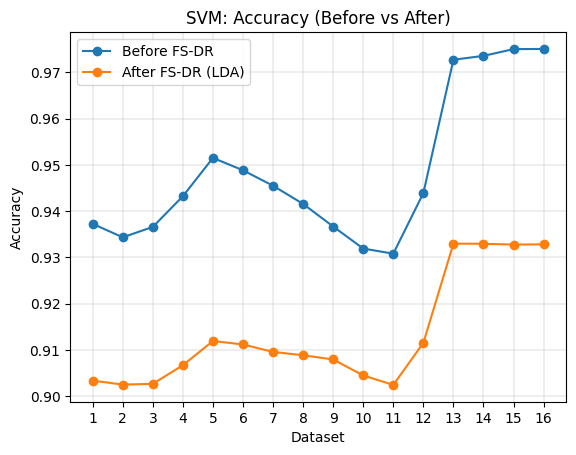

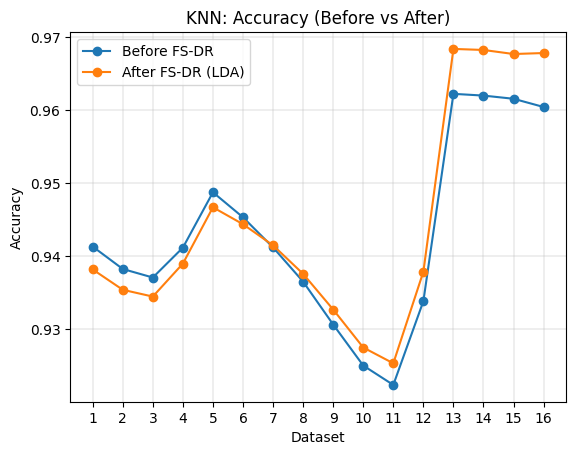

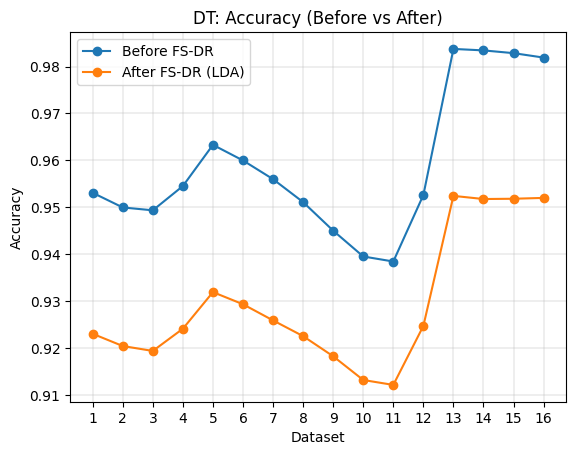

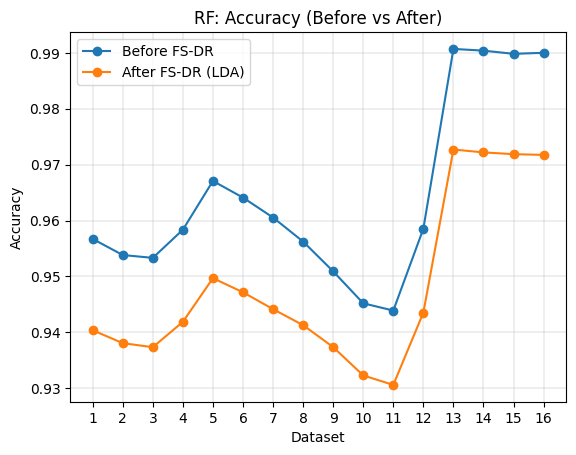

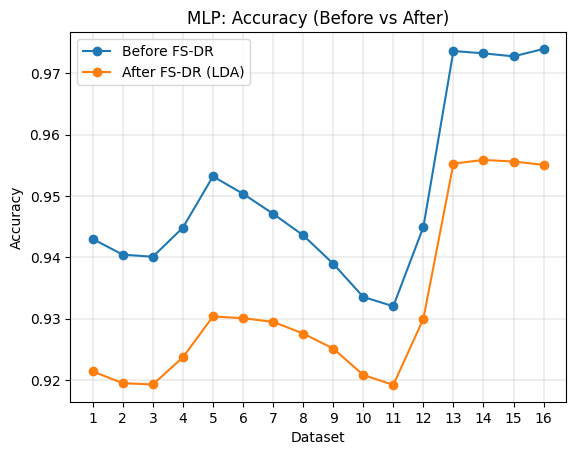

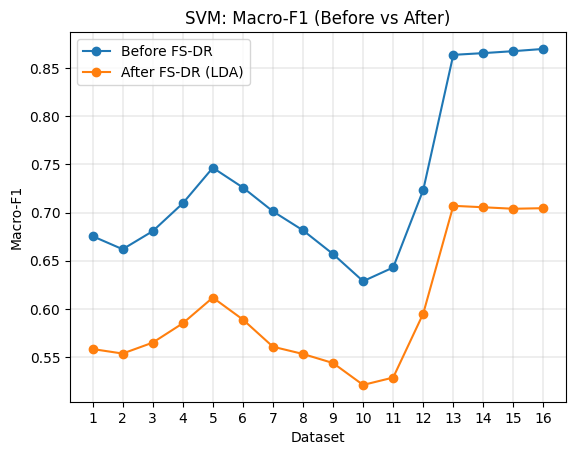

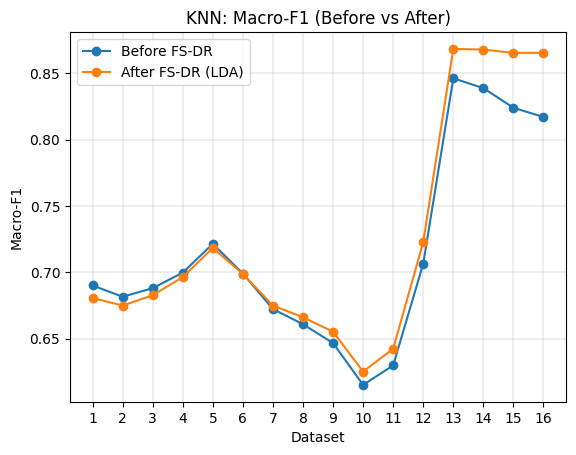

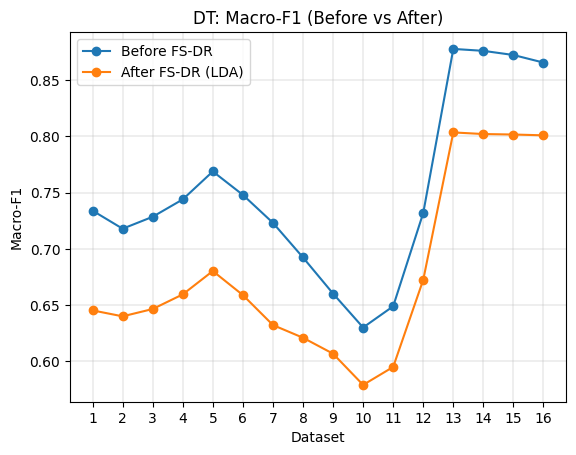

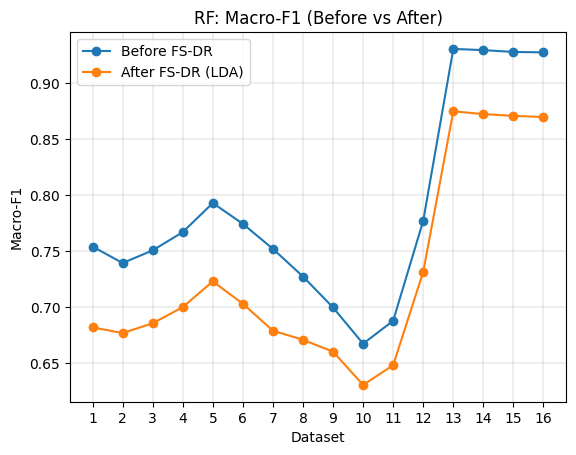

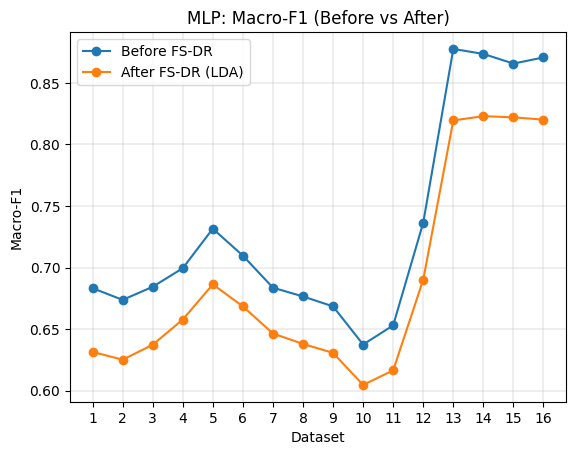

In [36]:
CLASSIFIERS = ["SVM", "KNN", "DT", "RF", "MLP"]

# 5 Accuracy graphs
for clf in CLASSIFIERS:
    plot_before_after(acc_pivot, clf, "Accuracy")

# 5 Macro-F1 graphs
for clf in CLASSIFIERS:
    plot_before_after(f1_pivot, clf, "Macro-F1")

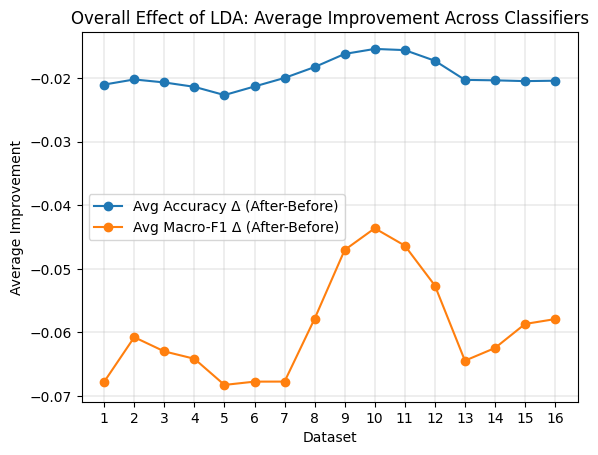

In [37]:
# Average delta across classifiers for each dataset
avg_acc_delta = acc_pivot.groupby("dataset")["Delta"].mean().reset_index()
avg_f1_delta  = f1_pivot.groupby("dataset")["Delta"].mean().reset_index()

plt.figure()
plt.plot(avg_acc_delta["dataset"], avg_acc_delta["Delta"], marker="o", label="Avg Accuracy Δ (After-Before)")
plt.plot(avg_f1_delta["dataset"],  avg_f1_delta["Delta"],  marker="o", label="Avg Macro-F1 Δ (After-Before)")
plt.xticks(avg_acc_delta["dataset"])
plt.xlabel("Dataset")
plt.ylabel("Average Improvement")
plt.title("Overall Effect of LDA: Average Improvement Across Classifiers")
plt.legend()
plt.grid(True, linewidth=0.3)
plt.show()

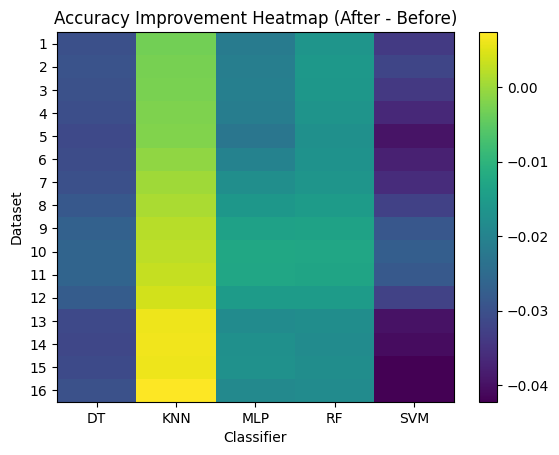

In [38]:
# Accuracy improvement matrix
acc_matrix = acc_pivot.pivot(index="dataset", columns="classifier", values="Delta").loc[range(1,17)]

plt.figure()
plt.imshow(acc_matrix.values, aspect="auto")
plt.xticks(range(len(acc_matrix.columns)), acc_matrix.columns)
plt.yticks(range(len(acc_matrix.index)), acc_matrix.index)
plt.xlabel("Classifier")
plt.ylabel("Dataset")
plt.title("Accuracy Improvement Heatmap (After - Before)")
plt.colorbar()
plt.show()